
--- Running Tier 1: Polynomial Regression (Trajectory Study) ---
SGD        | Loss: 0.00999 | Time: 0.02s
Adam       | Loss: 0.01340 | Time: 0.02s
L-BFGS     | Loss: 0.00999 | Time: 0.01s


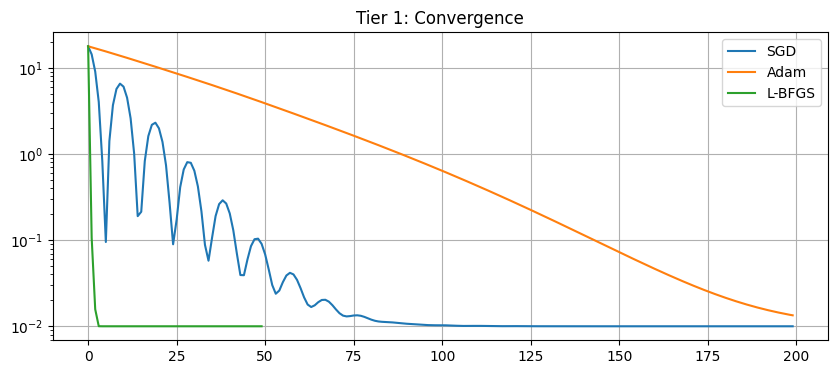

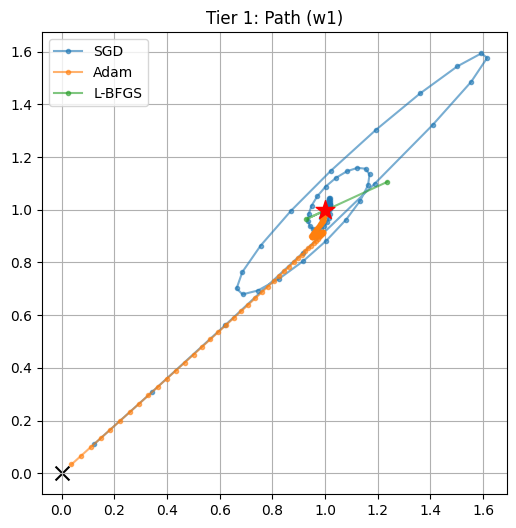


--- Running Tier 2: Spiral Classification ---
SGD        | Loss: 0.05247 | Acc: 0.8830 | Time: 7.07s
Adam       | Loss: 0.08278 | Acc: 0.6830 | Time: 1.99s
L-BFGS     | Loss: 0.10058 | Acc: 0.6000 | Time: 0.81s


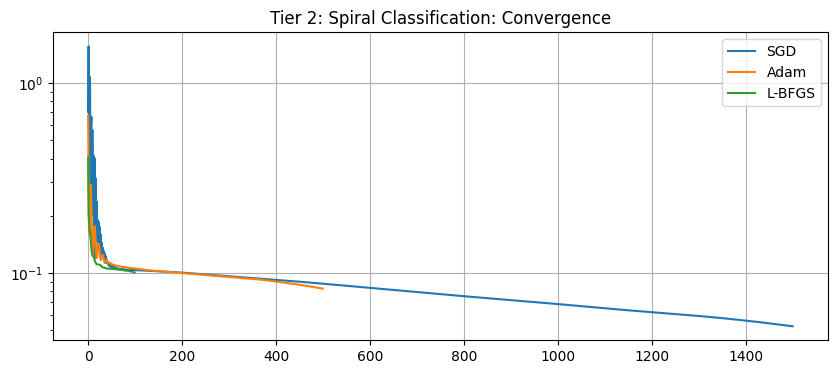

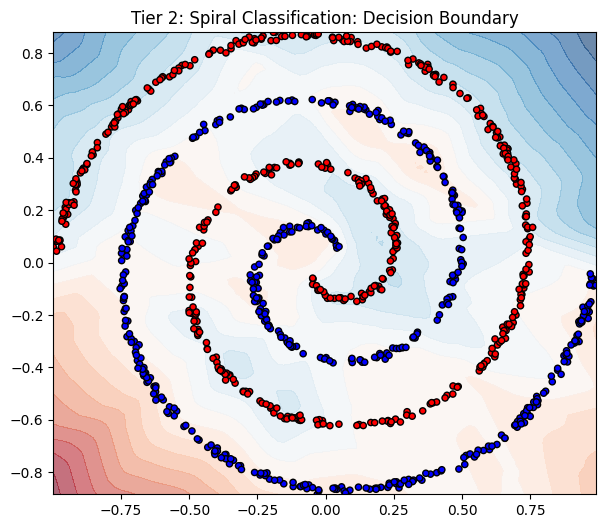

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# From Rose

# ==============================================================================
# PART 1: INFRASTRUCTURE & BACKEND
# ==============================================================================
class Parameter:
    def __init__(self, value):
        self.data = np.array(value, dtype=np.complex128)
        self.grad = np.zeros_like(self.data, dtype=np.complex128)
    def zero_grad(self):
        self.grad.fill(0)

class Module:
    def forward(self, x): raise NotImplementedError
    def backward(self, grad_output): raise NotImplementedError
    def parameters(self): return []

# ==============================================================================
# PART 2: LAYERS
# ==============================================================================
class ComplexLinear(Module):
    def __init__(self, in_features, out_features):
        scale = np.sqrt(1.0 / in_features)
        w_init = scale * (np.random.randn(in_features, out_features) +
                          1j * np.random.randn(in_features, out_features))
        b_init = np.zeros(out_features, dtype=np.complex128)
        self.W = Parameter(w_init); self.b = Parameter(b_init)
        self.input_cache = None
    def forward(self, x):
        self.input_cache = x
        return x @ self.W.data + self.b.data
    def backward(self, grad_output):
        x = self.input_cache
        self.W.grad += np.array(x.conj().T @ grad_output)
        self.b.grad += np.array(np.sum(grad_output, axis=0))
        return grad_output @ self.W.data.conj().T
    def parameters(self): return [self.W, self.b]

class ComplexReLU(Module):
    def __init__(self): self.mask_real = None; self.mask_imag = None
    def forward(self, x):
        self.mask_real = (x.real > 0); self.mask_imag = (x.imag > 0)
        return (x.real * self.mask_real) + 1j * (x.imag * self.mask_imag)
    def backward(self, grad_output):
        return (grad_output.real * self.mask_real) + 1j * (grad_output.imag * self.mask_imag)

class Sequential(Module):
    def __init__(self, layers): self.layers = layers
    def forward(self, x):
        for l in self.layers: x = l.forward(x)
        return x
    def backward(self, grad):
        for l in reversed(self.layers): grad = l.backward(grad)
        return grad
    def parameters(self): return [p for l in self.layers for p in l.parameters()]

class PolynomialModel(Module):
    """Explicit model for Tier 1 to allow w1 trajectory tracking."""
    def __init__(self):
        self.w1 = Parameter(0.0 + 0.0j); self.w2 = Parameter(0.0 + 0.0j); self.b = Parameter(0.0 + 0.0j)
        self.input_cache = None
    def forward(self, x):
        self.input_cache = x
        return self.w1.data * x**2 + self.w2.data * x + self.b.data
    def backward(self, grad_output):
        x = self.input_cache
        self.w1.grad += np.sum(grad_output * np.conj(x**2))
        self.w2.grad += np.sum(grad_output * np.conj(x))
        self.b.grad  += np.sum(grad_output * np.conj(1))
        return None
    def parameters(self): return [self.w1, self.w2, self.b]

# ==============================================================================
# PART 3: OPTIMIZERS (With Scalar Fixes)
# ==============================================================================
class ComplexOptimizer:
    def __init__(self, params, lr=1e-3):
        self.params = list(params); self.lr = lr; self.state = {}
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.fill(0)

class ComplexSGD(ComplexOptimizer):
    def __init__(self, params, lr=1e-3, momentum=0.0):
        super().__init__(params, lr); self.momentum = momentum
    def step(self, closure=None):
        loss = closure() if closure else None
        for p in self.params:
            if p.grad is None: continue
            d_p = p.grad
            if self.momentum != 0:
                buf = self.state.setdefault(id(p), {}).setdefault('momentum_buffer', np.zeros_like(p.data))
                buf[...] = (self.momentum * buf) + d_p
                d_p = buf
            p.data -= self.lr * d_p
        return loss

class ComplexAdam(ComplexOptimizer):
    def __init__(self, params, lr=1e-3):
        super().__init__(params, lr); self.betas=(0.9, 0.999); self.eps=1e-8
    def step(self, closure=None):
        loss = closure() if closure else None
        beta1, beta2 = self.betas
        for p in self.params:
            if p.grad is None: continue
            st = self.state.setdefault(id(p), {'step':0, 'm':np.zeros_like(p.data), 'v':np.zeros_like(p.data.real)})
            st['step'] += 1
            # FIX: Use [...] for in-place scalar updates
            st['m'][...] = beta1 * st['m'] + (1-beta1) * p.grad
            st['v'][...] = beta2 * st['v'] + (1-beta2) * (np.abs(p.grad)**2)
            denom = (np.sqrt(st['v']) / np.sqrt(1-beta2**st['step'])) + self.eps
            p.data -= (self.lr / (1-beta1**st['step'])) * (st['m'] / denom)
        return loss

class ComplexLBFGS(ComplexOptimizer):
    def __init__(self, params, lr=1.0, history_size=10):
        super().__init__(params, lr); self.history_size=history_size
    def _dot(self, a, b): return np.real(np.vdot(a, b))
    def step(self, closure=None):
        loss = closure()
        state = self.state.setdefault('global', {'step':0, 'ro':[], 's':[], 'y':[], 'pg':None, 'pp':None})
        flat_grad = np.concatenate([p.grad.ravel() for p in self.params])
        flat_params = np.concatenate([p.data.ravel() for p in self.params])
        if state['step'] > 0:
            y = flat_grad - state['pg']; s = flat_params - state['pp']
            ys = self._dot(y, s)
            if ys > 1e-10:
                rho = 1.0/ys
                if len(state['ro']) >= self.history_size:
                    state['ro'].pop(0); state['s'].pop(0); state['y'].pop(0)
                state['ro'].append(rho); state['s'].append(s); state['y'].append(y)
        q = flat_grad.copy(); alpha = []
        for i in range(len(state['ro']) - 1, -1, -1):
            a = state['ro'][i] * self._dot(state['s'][i], q); alpha.append(a)
            q -= a * state['y'][i]
        r = q * (self._dot(state['s'][-1], state['y'][-1])/self._dot(state['y'][-1], state['y'][-1])) if state['ro'] else q
        for i in range(len(state['ro'])):
            beta = state['ro'][i] * self._dot(state['y'][i], r)
            r += state['s'][i] * (alpha[len(state['ro'])-1-i] - beta)
        d = -r; step = self.lr; gtd = self._dot(flat_grad, d)
        for _ in range(10):
            new_p = flat_params + step*d
            offset=0
            for p in self.params:
                sz = p.data.size; p.data[...] = new_p[offset:offset+sz].reshape(p.data.shape); offset+=sz
            if closure() <= loss + 1e-4*step*gtd: break
            step *= 0.5
        state['pg'] = flat_grad; state['pp'] = flat_params; state['step'] += 1
        return loss

# ==============================================================================
# PART 4: VISUALIZATION
# ==============================================================================
class Visualizer:
    @staticmethod
    def plot_convergence(results, title):
        plt.figure(figsize=(10, 4))
        for name, data in results.items(): plt.plot(data['loss'], label=name)
        plt.yscale('log'); plt.title(f"{title}: Convergence"); plt.legend(); plt.grid(True); plt.show()
    @staticmethod
    def plot_trajectory(results, title):
        plt.figure(figsize=(6, 6))
        for name, data in results.items():
            if 'w_hist' in data: plt.plot(np.array(data['w_hist']).real, np.array(data['w_hist']).imag, '.-', label=name, alpha=0.6)
        plt.scatter([0], [0], c='k', marker='x', s=100); plt.scatter([1], [1], c='r', marker='*', s=200, zorder=10)
        plt.title(f"{title}: Path (w1)"); plt.axis('equal'); plt.legend(); plt.grid(True); plt.show()
    @staticmethod
    def plot_decision_boundary(model, X, y, title):
        r = np.linspace(X.real.min(), X.real.max(), 100); i = np.linspace(X.imag.min(), X.imag.max(), 100)
        rr, ii = np.meshgrid(r, i); z = (rr + 1j*ii).reshape(-1, 1)
        vals = model.forward(z).real.reshape(100, 100)
        plt.figure(figsize=(7, 6)); plt.contourf(rr, ii, vals, levels=20, cmap='RdBu', alpha=0.6)
        plt.scatter(X.real, X.imag, c=y.real.ravel(), edgecolors='k', cmap='bwr', s=20); plt.title(f"{title}: Decision Boundary"); plt.show()
    @staticmethod
    def plot_constellation(model, X, y, title):
        yp = model.forward(X)
        plt.figure(figsize=(6, 6)); plt.scatter(yp.real, yp.imag, alpha=0.3, c='b', label='Recovered')
        plt.scatter(y.real, y.imag, alpha=0.8, c='r', marker='x', label='True'); plt.title(f"{title}: Constellation"); plt.axis('equal'); plt.legend(); plt.grid(True); plt.show()

# ==============================================================================
# PART 5: EXECUTION & METRICS
# ==============================================================================
def get_data(tier, n=1000):
    np.random.seed(42)
    if tier == 1:
        z = (np.random.rand(n)+0.5)*np.exp(1j*np.random.uniform(0, 2*np.pi, n))
        y = (1+1j)*z**2 + (-2+2j)*z + 5 + 0.1*(np.random.randn(n)+1j*np.random.randn(n))
        return z.reshape(-1,1), y.reshape(-1,1)
    elif tier == 2:
        n2=n//2; t = np.sqrt(np.random.rand(n2))*4*np.pi
        z0 = (t+np.random.randn(n2)*0.1)*np.exp(1j*t)
        z1 = (t+np.random.randn(n2)*0.1)*np.exp(1j*(t+np.pi))
        X = np.concatenate([z0,z1]); y = np.concatenate([np.zeros(n2),np.ones(n2)])
        X /= np.max(np.abs(X)) # Normalize
        return X.reshape(-1,1), y.reshape(-1,1)
    elif tier == 3:
        b = np.random.randint(0,2,(n,2))*2-1; s = b[:,0]+1j*b[:,1]
        x = (0.5+0.5j)*s + 0.2*(np.random.randn(n)+1j*np.random.randn(n))
        return x.reshape(-1,1), s.reshape(-1,1)

def run_tier_1():
    print(f"\n--- Running Tier 1: Polynomial Regression (Trajectory Study) ---")
    X, y = get_data(1); y = y.astype(np.complex128)
    def calc_loss(yp, yt): d=yp-yt; return 0.5*np.mean(np.abs(d)**2), (1.0/len(yt))*d

    configs = [("SGD", lambda p: ComplexSGD(p, 0.1, 0.9)), ("Adam", lambda p: ComplexAdam(p, 0.05)), ("L-BFGS", lambda p: ComplexLBFGS(p, 1.0))]
    epochs_map = {"L-BFGS": 50, "SGD": 200, "Adam": 200}; results = {}

    for name, opt_fn in configs:
        model = PolynomialModel(); opt = opt_fn(model.parameters()); hist = {'loss': [], 'w_hist': []}
        start = time.time()
        for _ in range(epochs_map[name]):
            def closure(): opt.zero_grad(); l, g = calc_loss(model.forward(X), y); model.backward(g); return l
            hist['loss'].append(opt.step(closure)); hist['w_hist'].append(model.w1.data.copy())
        print(f"{name:<10} | Loss: {hist['loss'][-1]:.5f} | Time: {time.time()-start:.2f}s")
        results[name] = hist
    Visualizer.plot_convergence(results, "Tier 1"); Visualizer.plot_trajectory(results, "Tier 1")

# Updated generic runner that handles metrics
def run_generic_tier(tier_id, title, model_fn, configs, epochs_map, metric_fn=None, metric_name="Metric"):
    print(f"\n--- Running {title} ---")
    X, y = get_data(tier_id); y = y.astype(np.complex128)
    def calc_loss(yp, yt): d=yp-yt; return 0.5*np.mean(np.abs(d)**2), (1.0/len(yt))*d

    results = {}; best_model = None; min_loss = float('inf')

    for name, opt_fn in configs:
        model = model_fn(); opt = opt_fn(model.parameters()); hist = {'loss': []}
        start = time.time()
        for _ in range(epochs_map.get(name, 100)):
            def closure(): opt.zero_grad(); l, g = calc_loss(model.forward(X), y); model.backward(g); return l
            hist['loss'].append(opt.step(closure))

        # Calculate Metric
        metric_val = 0.0
        if metric_fn:
            metric_val = metric_fn(model, X, y)

        dur = time.time()-start
        print(f"{name:<10} | Loss: {hist['loss'][-1]:.5f} | {metric_name}: {metric_val:.4f} | Time: {dur:.2f}s")
        results[name] = hist
        if hist['loss'][-1] < min_loss: min_loss = hist['loss'][-1]; best_model = model

    Visualizer.plot_convergence(results, title)
    if tier_id == 2: Visualizer.plot_decision_boundary(best_model, X, y, title)
    elif tier_id == 3: Visualizer.plot_constellation(best_model, X, y, title)

if __name__ == "__main__":
    # Tier 1
    run_tier_1()

    # Tier 2: Metric = Classification Accuracy
    def calc_acc(m, x, y):
        pred = m.forward(x)
        return np.mean((pred.real > 0.5) == (y.real > 0.5))

    run_generic_tier(2, "Tier 2: Spiral Classification",
             lambda: Sequential([ComplexLinear(1, 100), ComplexReLU(), ComplexLinear(100, 1)]),
             [("SGD", lambda p: ComplexSGD(p, 0.1, 0.9)), ("Adam", lambda p: ComplexAdam(p, 0.01)), ("L-BFGS", lambda p: ComplexLBFGS(p, 0.5))],
             {"SGD": 1500, "Adam": 500, "L-BFGS": 100},
             metric_fn=calc_acc, metric_name="Acc")

    # # Tier 3: Metric = Symbol Error Rate (SER)
    # def calc_ser(m, x, y):
    #     pred = m.forward(x)
    #     # Error if sign of real OR imag part is wrong (Quadrant check)
    #     errs = (np.sign(pred.real) != np.sign(y.real)) | (np.sign(pred.imag) != np.sign(y.imag))
    #     return np.mean(errs)

    # run_generic_tier(3, "Tier 3: Channel Equalization",
    #          lambda: Sequential([ComplexLinear(1, 10), ComplexReLU(), ComplexLinear(10, 1)]),
    #          [("SGD", lambda p: ComplexSGD(p, 0.1, 0.9)), ("Adam", lambda p: ComplexAdam(p, 0.01)), ("L-BFGS", lambda p: ComplexLBFGS(p, 1.0))],
    #          {"L-BFGS": 50, "SGD": 200, "Adam": 200},
    #          metric_fn=calc_ser, metric_name="SER")